## **Import the necessary libraries**
- we import the necessary libraries to be used in the dataset

In [25]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report


# **Load the dataset**

- We load the dataset

In [26]:
#Load the dataset
df = pd.read_csv('global_graduate_employability_index.csv')
df.head()

,Country,Region,University_Name,Degree_Level,Field_of_Study,Graduation_Year,Employment_Rate_6_Months (%),Employment_Rate_12_Months (%),Average_Starting_Salary_USD,Top_Industry,Job_Role,Skill_1,Skill_2,Skill_3,Skill_Demand_Score (1–100),Remote_Work_Availability (%),Employer_Reputation_Score (1–100),Year
0,USA,North America,Harvard,Bachelor,Engineering,2017,79.3,85.6,66700,Manufacturing/Construction,Robotics Engineer,AutoCAD,Lean Six Sigma,MATLAB,69,8.8,66,2017
1,USA,North America,MIT,Bachelor,Engineering,2023,83.8,87.9,84500,Manufacturing/Construction,Civil Engineer,Lean Six Sigma,AutoCAD,MATLAB,71,65.4,63,2023
2,Israel,Middle East & Africa,Technion,Master,Healthcare & Medicine,2019,81.7,83.2,88300,Healthcare,Public Health Specialist,Clinical Research,Diagnostics,Patient Care,52,5.0,74,2019
3,India,Asia-Pacific,IIT Bombay,Master,Computer Science,2016,84.2,92.1,21000,Technology,AI Researcher,DevOps,Python,Cloud Computing,69,10.3,48,2016
4,South Africa,Middle East & Africa,University of Cape Town,PhD,Business & Finance,2023,83.6,86.3,48600,Finance/Consulting,Management Consultant,Financial Modeling,Data Analysis,Market Research,69,64.0,65,2023


## **Data Quality Checks**
 - Basic summarry statistics
 - Data types
 - Missing values
 - checking for outliers

In [27]:
#checking the shape of the dataset
df.shape
print(f'Number of rows in the dataset: {df.shape[0]}')
print(f'Number of columns in the dataset: {df.shape[1]}')

Number of rows in the dataset: 3500
Number of columns in the dataset: 18


The above output shows the number of rows and columns for the dataset. we have 18 variables, 15 independent variables and 3 dependent variables in the dataset

In [28]:
df.describe()

,Graduation_Year,Employment_Rate_6_Months (%),Employment_Rate_12_Months (%),Average_Starting_Salary_USD,Skill_Demand_Score (1–100),Remote_Work_Availability (%),Employer_Reputation_Score (1–100),Year
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,2020.021143,85.735486,90.409857,64668.000000,65.187429,40.060886,69.742286,2020.021143
std,3.198601,6.986723,6.743580,30727.510224,14.710632,30.318816,14.243037,3.198601
min,2015.000000,65.500000,68.000000,-1200.000000,30.000000,5.000000,40.000000,2015.000000
25%,2017.000000,80.700000,85.500000,39400.000000,55.000000,10.600000,60.000000,2017.000000
50%,2020.000000,85.600000,90.600000,63900.000000,64.000000,37.300000,70.000000,2020.000000
75%,2023.000000,90.900000,96.000000,85400.000000,75.000000,68.300000,79.250000,2023.000000
max,2025.000000,99.000000,100.000000,189400.000000,100.000000,90.000000,100.000000,2025.000000


In [29]:
df.value_counts()

Country       Region                University_Name             Degree_Level  Field_of_Study         Graduation_Year  Employment_Rate_6_Months (%)  Employment_Rate_12_Months (%)  Average_Starting_Salary_USD  Top_Industry                Job_Role                  Skill_1               Skill_2               Skill_3               Skill_Demand_Score (1–100)  Remote_Work_Availability (%)  Employer_Reputation_Score (1–100)  Year
Argentina     Latin America         University of Buenos Aires  Bachelor      Business & Finance     2015             80.4                          87.8                           13800                        Finance/Consulting          Investment Banker         Market Research       Excel                 Financial Modeling    52                          6.7                           75                                 2015    1
South Africa  Middle East & Africa  University of Cape Town     Bachelor      Business & Finance     2016             80.9                     

In [30]:
#checking for missing values
df.isnull().sum()

Country                              0
Region                               0
University_Name                      0
Degree_Level                         0
Field_of_Study                       0
Graduation_Year                      0
Employment_Rate_6_Months (%)         0
Employment_Rate_12_Months (%)        0
Average_Starting_Salary_USD          0
Top_Industry                         0
Job_Role                             0
Skill_1                              0
Skill_2                              0
Skill_3                              0
Skill_Demand_Score (1–100)           0
Remote_Work_Availability (%)         0
Employer_Reputation_Score (1–100)    0
Year                                 0
dtype: int64

We don't have missing values in our dataset.

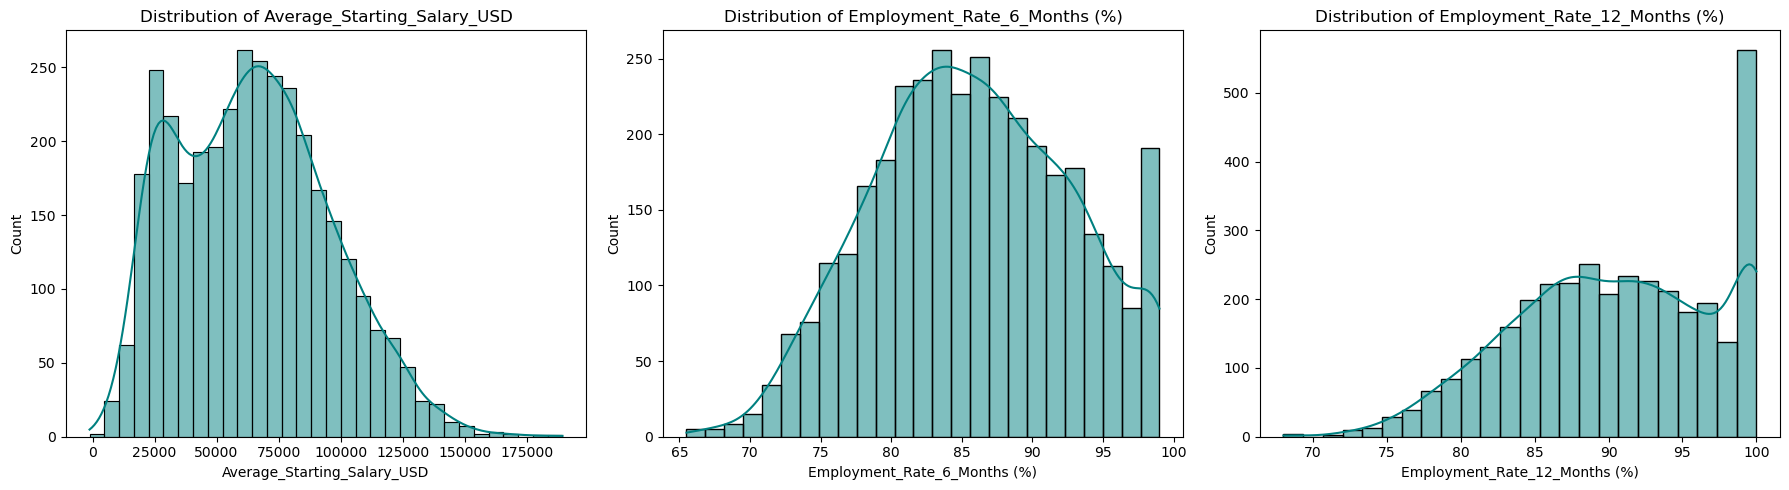

In [31]:
# Identify target columns
targets = ['Average_Starting_Salary_USD', 'Employment_Rate_6_Months (%)', 'Employment_Rate_12_Months (%)']

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot histograms for each target
for i, col in enumerate(targets):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [32]:
#check information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Country                            3500 non-null   object 
 1   Region                             3500 non-null   object 
 2   University_Name                    3500 non-null   object 
 3   Degree_Level                       3500 non-null   object 
 4   Field_of_Study                     3500 non-null   object 
 5   Graduation_Year                    3500 non-null   int64  
 6   Employment_Rate_6_Months (%)       3500 non-null   float64
 7   Employment_Rate_12_Months (%)      3500 non-null   float64
 8   Average_Starting_Salary_USD        3500 non-null   int64  
 9   Top_Industry                       3500 non-null   object 
 10  Job_Role                           3500 non-null   object 
 11  Skill_1                            3500 non-null   objec

- **Checking for duplicates**

In [33]:
#Count total duplicate rows across all columns
duplicates_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicates_count}")

#To see the actual duplicate rows (if any existed)
if duplicates_count > 0:
    duplicate_rows = df[df.duplicated()]
    print(duplicate_rows)

#Check for duplicates in specific columns (e.g., University_Name and Graduation_Year)
#This is useful if a student shouldn't appear twice for the same year/university
specific_duplicates = df.duplicated(subset=['University_Name', 'Graduation_Year', 'Field_of_Study']).sum()
print(f"Duplicates based on specific columns: {specific_duplicates}")

Total duplicate rows: 0
Duplicates based on specific columns: 1522


In [34]:
# View duplicates based on specific columns
subset_duplicates = df[df.duplicated(subset=['University_Name', 'Graduation_Year'], keep=False)]
print(subset_duplicates)

           Country                Region                 University_Name  \
0              USA         North America                         Harvard   
1              USA         North America                             MIT   
2           Israel  Middle East & Africa                        Technion   
3            India          Asia-Pacific                      IIT Bombay   
4     South Africa  Middle East & Africa         University of Cape Town   
...            ...                   ...                             ...   
3495        Israel  Middle East & Africa  Hebrew University of Jerusalem   
3496         Japan          Asia-Pacific                Kyoto University   
3497     Australia          Asia-Pacific            University of Sydney   
3498           UAE  Middle East & Africa              Khalifa University   
3499   Switzerland                Europe                            EPFL   

     Degree_Level         Field_of_Study  Graduation_Year  \
0        Bachelor         

In [36]:
# Finding rows where University, Degree, and Graduation Year are the same
subset_cols = ['University_Name', 'Degree_Level', 'Graduation_Year']
subset_duplicates = df[df.duplicated(subset=subset_cols, keep=False)]

print(f"Showing rows with same University, Degree, and Year:")
print(subset_duplicates.sort_values(by=subset_cols).head(10))

Showing rows with same University, Degree, and Year:
        Country        Region University_Name Degree_Level     Field_of_Study  \
520   Australia  Asia-Pacific             ANU     Bachelor    Social Sciences   
1842  Australia  Asia-Pacific             ANU     Bachelor  Data Science & AI   
3354  Australia  Asia-Pacific             ANU     Bachelor    Social Sciences   
3009  Australia  Asia-Pacific             ANU     Bachelor        Engineering   
3026  Australia  Asia-Pacific             ANU     Bachelor    Social Sciences   
2437  Australia  Asia-Pacific             ANU     Bachelor        Engineering   
2441  Australia  Asia-Pacific             ANU     Bachelor   Computer Science   
741   Australia  Asia-Pacific             ANU     Bachelor   Natural Sciences   
1613  Australia  Asia-Pacific             ANU     Bachelor        Engineering   
2302  Australia  Asia-Pacific             ANU     Bachelor        Engineering   

      Graduation_Year  Employment_Rate_6_Months (%)  \


In [37]:
# Statistical summary of numerical columns
print(df.describe())

# Check how many graduates are in each Field of Study
print(df['Field_of_Study'].value_counts())

# Check Average Salary by Degree Level
print(df.groupby('Degree_Level')['Average_Starting_Salary_USD'].mean())

       Graduation_Year  Employment_Rate_6_Months (%)  \
count      3500.000000                   3500.000000   
mean       2020.021143                     85.735486   
std           3.198601                      6.986723   
min        2015.000000                     65.500000   
25%        2017.000000                     80.700000   
50%        2020.000000                     85.600000   
75%        2023.000000                     90.900000   
max        2025.000000                     99.000000   

       Employment_Rate_12_Months (%)  Average_Starting_Salary_USD  \
count                    3500.000000                  3500.000000   
mean                       90.409857                 64668.000000   
std                         6.743580                 30727.510224   
min                        68.000000                 -1200.000000   
25%                        85.500000                 39400.000000   
50%                        90.600000                 63900.000000   
75%         

In [ ]:
# Check for duplicate ROWS
# duplicated() returns a boolean Series indicating whether each row is a duplicate
duplicate_rows_count = df.duplicated().sum()
duplicate_rows = df[df.duplicated()]

print(f"Total Duplicate Rows: {duplicate_rows_count}")

#Check for duplicate COLUMNS
# A function to compare every column with every other column to find identical values
def get_duplicate_columns(df):
    duplicate_columns = []
    for i in range(len(df.columns)):
        col1 = df.iloc[:, i]
        for j in range(i + 1, len(df.columns)):
            col2 = df.iloc[:, j]
            # If all values in both columns are equal
            if col1.equals(col2):
                duplicate_columns.append((df.columns[i], df.columns[j]))
    return duplicate_columns

duplicate_cols = get_duplicate_columns(df)

if duplicate_cols:
    print("\nDuplicate Column Pairs Found:")
    for col_pair in duplicate_cols:
        print(f" - '{col_pair[1]}' is identical to '{col_pair[0]}'")
else:
    print("\nNo duplicate columns found.")

Total Duplicate Rows: 0

Duplicate Column Pairs Found:
 - 'Year' is identical to 'Graduation_Year'


In [39]:
# Displaying the first 10 rows of the identical columns for comparison
print("Comparing 'Graduation_Year' and 'Year':")
print(df[['Graduation_Year', 'Year']].head(10))

# Confirm they are 100% identical
are_identical = df['Graduation_Year'].equals(df['Year'])
print(f"\nAre the columns identical? {are_identical}")

Comparing 'Graduation_Year' and 'Year':
   Graduation_Year  Year
0             2017  2017
1             2023  2023
2             2019  2019
3             2016  2016
4             2023  2023
5             2015  2015
6             2025  2025
7             2025  2025
8             2023  2023
9             2016  2016

Are the columns identical? True


- **Checking for outliers**

Column: Graduation_Year | Outlier Count: 0
Column: Employment_Rate_6_Months (%) | Outlier Count: 0
Column: Employment_Rate_12_Months (%) | Outlier Count: 4
Column: Average_Starting_Salary_USD | Outlier Count: 7
Column: Skill_Demand_Score (1–100) | Outlier Count: 0
Column: Remote_Work_Availability (%) | Outlier Count: 0
Column: Employer_Reputation_Score (1–100) | Outlier Count: 0
Column: Year | Outlier Count: 0


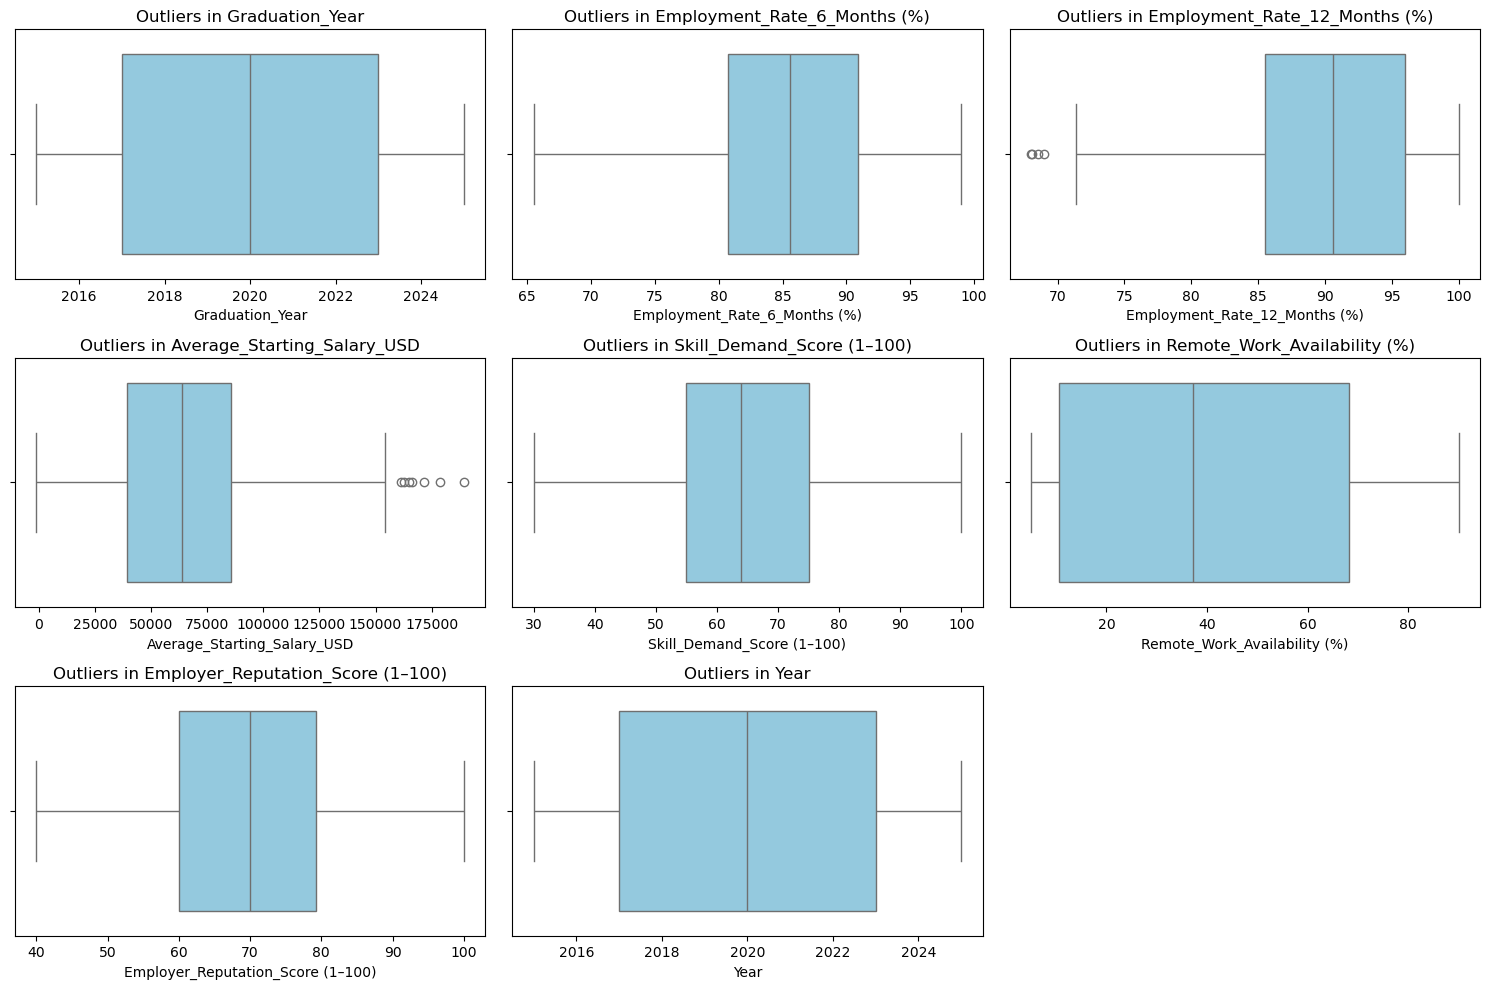

In [40]:
#Select numerical columns
num_cols = df.select_dtypes(include=['number']).columns

#Calculate outliers and display summary
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    #Identify outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Column: {col} | Outlier Count: {len(outliers)}")

#Generate Box Plots to visualize outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.savefig('outlier_plots.png')

## **Data Cleaning**
  - Handling outliers

Outliers capped for: Employment_Rate_12_Months (%)
Outliers capped for: Average_Starting_Salary_USD


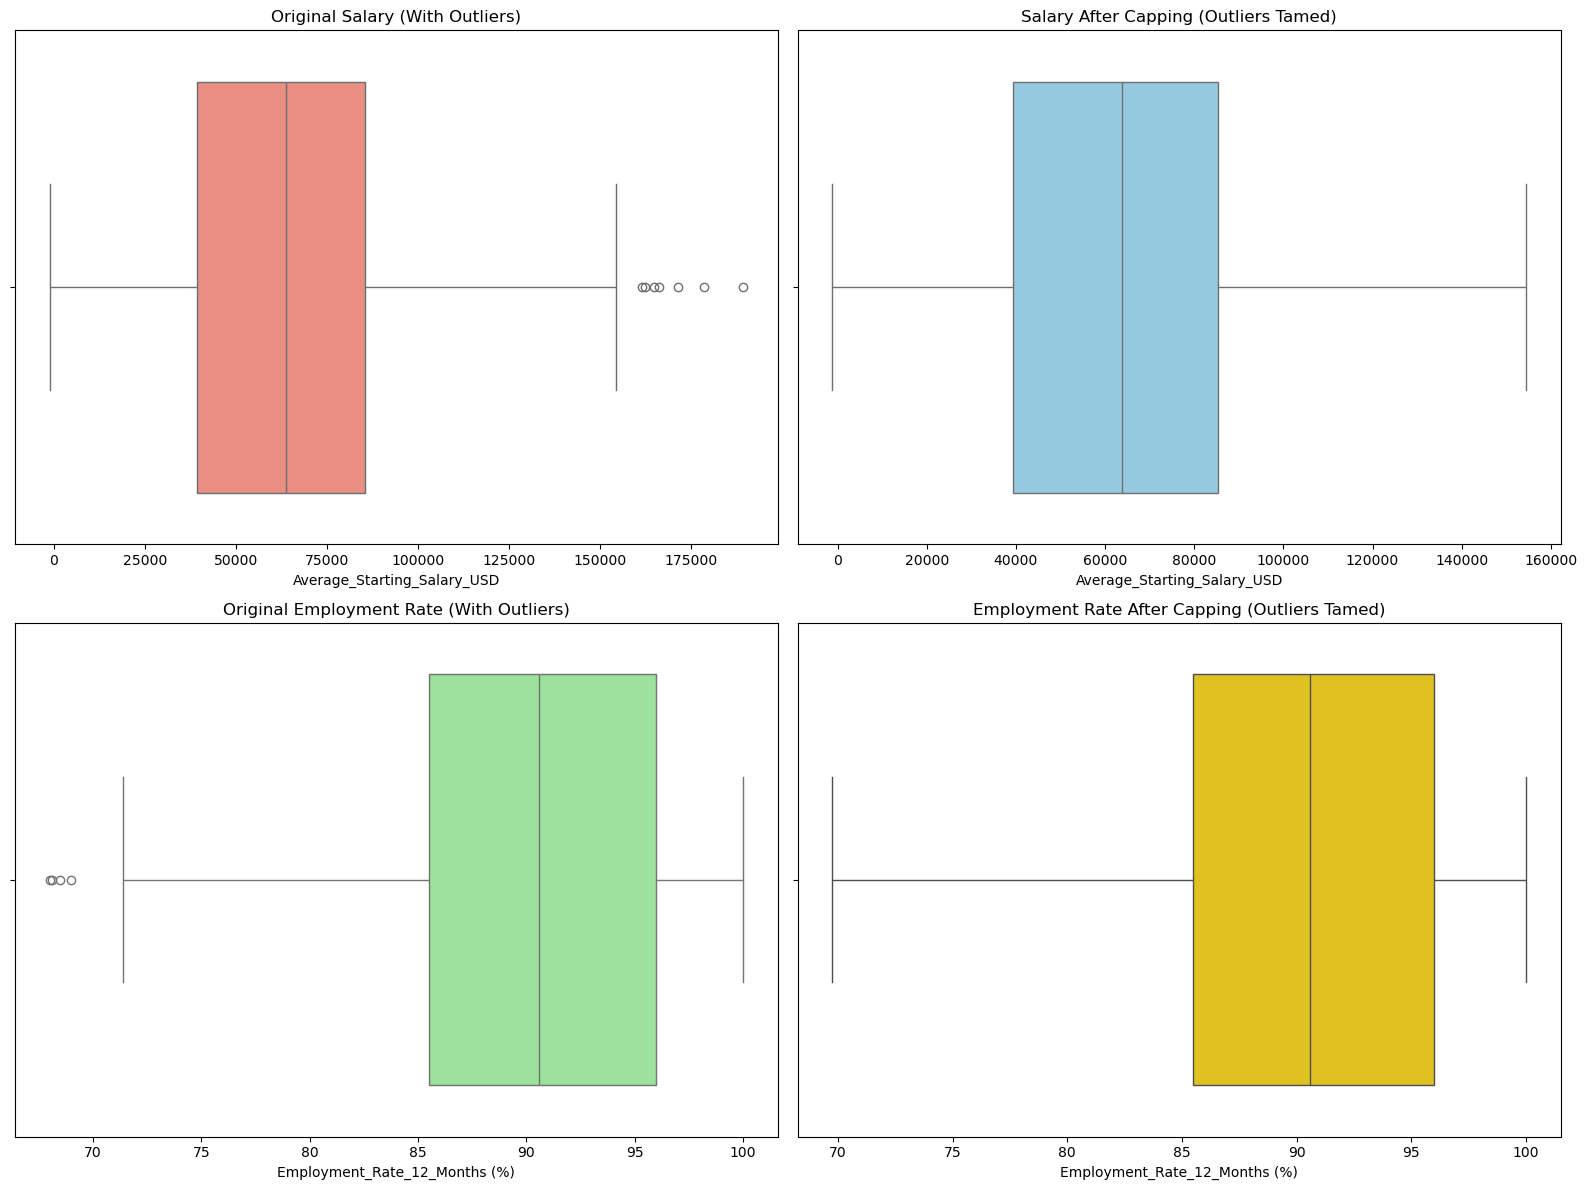

In [ ]:
1.#Clean column names (remove any trailing spaces)
df.columns = df.columns.str.strip()

# Identify numerical columns for scaling later
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# 2. Handle Outliers via Capping (Winsorization)
# Targeted columns based on the outlier analysis
cols_to_treat = ['Employment_Rate_12_Months (%)', 'Average_Starting_Salary_USD']

# Store a copy for visualization comparison
df_original = df.copy()

for col in cols_to_treat:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    # Capping: Values outside the bounds are set to the bound value
    # This removes the extreme "pull" of outliers without deleting data rows
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    print(f"Outliers capped for: {col}")

# 3. Feature Scaling (Standardization)
# Most ML models require features on the same scale
scaler = StandardScaler()
df_processed = df.copy()

# Fit and transform the numerical columns
df_processed[num_cols] = scaler.fit_transform(df[num_cols])

# 4. Visualization: Before vs After Treatment (Salary and Employment Rate)
# Creating a 2x2 grid to show both columns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Row 1: Average Starting Salary
sns.boxplot(data=df_original, x='Average_Starting_Salary_USD', ax=axes[0, 0], color='salmon')
axes[0, 0].set_title('Original Salary (With Outliers)')

sns.boxplot(data=df, x='Average_Starting_Salary_USD', ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Salary After Capping (Outliers Tamed)')

# Row 2: Employment Rate 12 Months
sns.boxplot(data=df_original, x='Employment_Rate_12_Months (%)', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Original Employment Rate (With Outliers)')

sns.boxplot(data=df, x='Employment_Rate_12_Months (%)', ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Employment Rate After Capping (Outliers Tamed)')

plt.tight_layout()
plt.savefig('outlier_treatment_comparison.png')
plt.show()

# Save the final cleaned and scaled data for model training
df_processed.to_csv('processed_graduate_employability.csv', index=False)

- Dropping duplicates

In [43]:
# Dropping a single column
df = df.drop('Year', axis=1, errors='ignore')

print(df.columns.tolist())

['Country', 'Region', 'University_Name', 'Degree_Level', 'Field_of_Study', 'Graduation_Year', 'Employment_Rate_6_Months (%)', 'Employment_Rate_12_Months (%)', 'Average_Starting_Salary_USD', 'Top_Industry', 'Job_Role', 'Skill_1', 'Skill_2', 'Skill_3', 'Skill_Demand_Score (1–100)', 'Remote_Work_Availability (%)', 'Employer_Reputation_Score (1–100)']


In [44]:
df.head(10)

,Country,Region,University_Name,Degree_Level,Field_of_Study,Graduation_Year,Employment_Rate_6_Months (%),Employment_Rate_12_Months (%),Average_Starting_Salary_USD,Top_Industry,Job_Role,Skill_1,Skill_2,Skill_3,Skill_Demand_Score (1–100),Remote_Work_Availability (%),Employer_Reputation_Score (1–100)
0,USA,North America,Harvard,Bachelor,Engineering,2017,79.3,85.6,66700,Manufacturing/Construction,Robotics Engineer,AutoCAD,Lean Six Sigma,MATLAB,69,8.8,66
1,USA,North America,MIT,Bachelor,Engineering,2023,83.8,87.9,84500,Manufacturing/Construction,Civil Engineer,Lean Six Sigma,AutoCAD,MATLAB,71,65.4,63
2,Israel,Middle East & Africa,Technion,Master,Healthcare & Medicine,2019,81.7,83.2,88300,Healthcare,Public Health Specialist,Clinical Research,Diagnostics,Patient Care,52,5.0,74
3,India,Asia-Pacific,IIT Bombay,Master,Computer Science,2016,84.2,92.1,21000,Technology,AI Researcher,DevOps,Python,Cloud Computing,69,10.3,48
4,South Africa,Middle East & Africa,University of Cape Town,PhD,Business & Finance,2023,83.6,86.3,48600,Finance/Consulting,Management Consultant,Financial Modeling,Data Analysis,Market Research,69,64.0,65
5,South Africa,Middle East & Africa,University of Cape Town,PhD,Computer Science,2015,99.0,100.0,39200,Technology,Software Engineer,React,Java,Cloud Computing,59,14.1,51
6,UK,Europe,LSE,Master,Business & Finance,2025,71.5,73.8,86000,Finance/Consulting,Management Consultant,Excel,Strategic Planning,Data Analysis,71,90.0,72
7,Sweden,Europe,Karolinska Institute,PhD,Social Sciences,2025,81.5,83.5,79800,Government/NGO,Economist,Public Policy,Communication,Data Analysis,62,85.4,85
8,Netherlands,Europe,University of Amsterdam,Master,Social Sciences,2023,72.4,78.1,60900,Government/NGO,Policy Analyst,Qualitative Research,Communication,Data Analysis,62,63.2,79
9,UK,Europe,Imperial College London,Master,Data Science & AI,2016,95.9,99.2,78800,Technology/Consulting,Data Analyst,Deep Learning,Big Data,R,68,11.7,84


## **Exploratory Data Analysis**

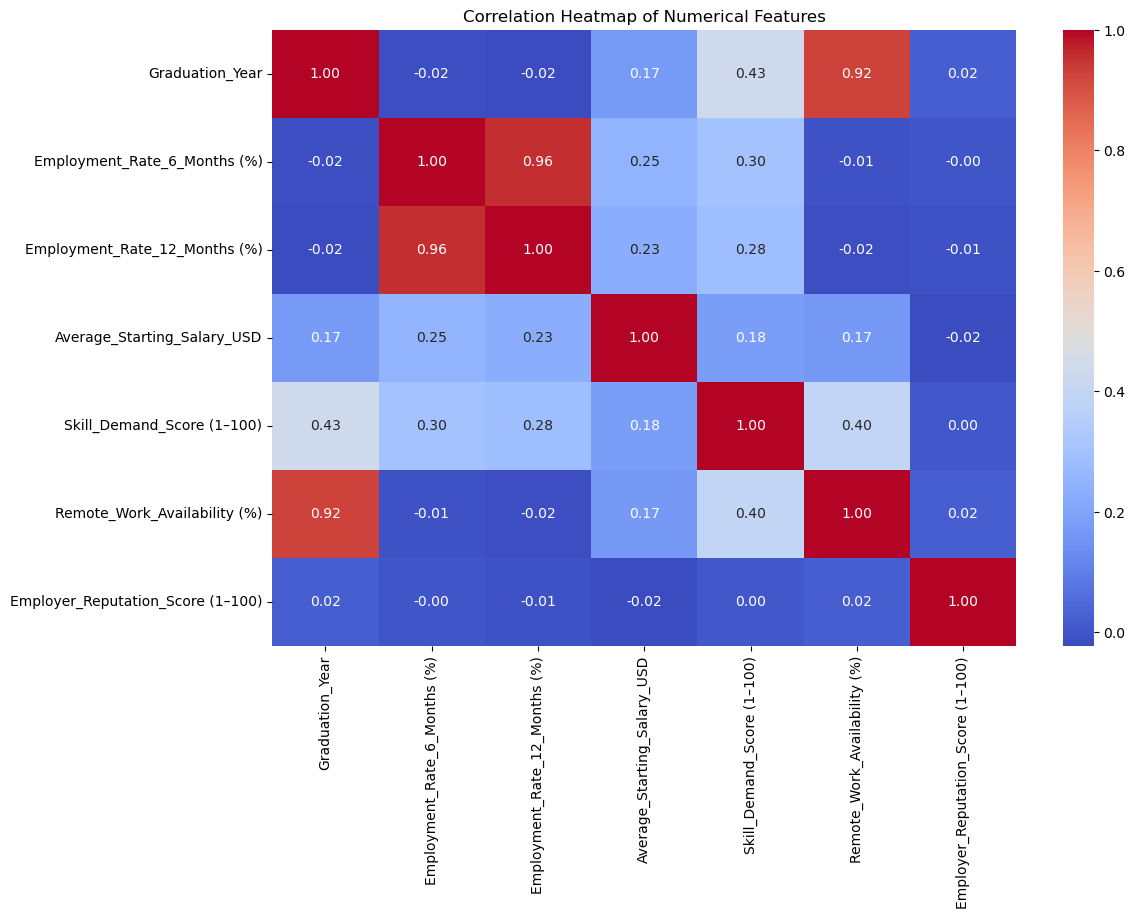

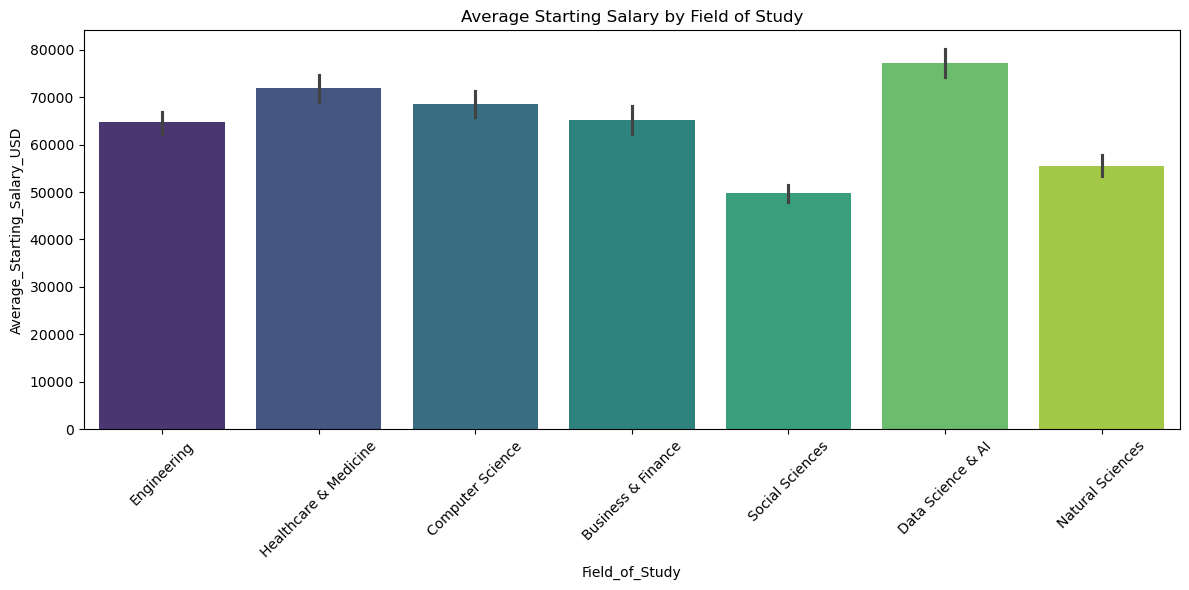

In [45]:
#Correlation Heatmap
#This helps identify which variables impact employability most.
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig('correlation_heatmap.png')

#Visualizing Key Drivers (Fixing the deprecation warning)
#We assign x to hue to use the 'viridis' palette without a warning.
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df, 
    x='Field_of_Study', 
    y='Average_Starting_Salary_USD', 
    hue='Field_of_Study', 
    palette='viridis'
)

#Removing the legend since each bar is already labeled on the X-axis
if ax.get_legend():
    ax.get_legend().remove()

plt.xticks(rotation=45)
plt.title('Average Starting Salary by Field of Study')
plt.tight_layout()
plt.savefig('salary_by_field.png')

#Target Creation for Classification
#As per the project plan, defining 'High_Employability' as a binary target.
threshold = df['Employment_Rate_12_Months (%)'].median()
df['High_Employability'] = (df['Employment_Rate_12_Months (%)'] > threshold).astype(int)

## Dropping leakage columns

In [50]:
#DROP LEAKAGE COLUMNS FIRST 
#These correlate highly but are "cheating" variables (outcomes)
leakage_cols = ['Employment_Rate_6_Months (%)', 'Average_Starting_Salary_USD', 'Top_Industry', 'Job_Role', 'Graduation_Year', 'Year', 'University_Name', 'Country', 'Region']
df = df.drop(columns=leakage_cols, errors='ignore')

#CALCULATE CORRELATION SAFELY
#We use 'numeric_only=True' to avoid the ValueError you encountered
target = 'Employment_Rate_12_Months (%)'
correlations = df.corr(numeric_only=True)[target].abs().sort_values(ascending=False)

#IDENTIFY COLUMNS TO DROP
#We define "low correlation" as any value less than 0.1
threshold = 0.1
low_corr_cols = correlations[correlations < threshold].index.tolist()

print("Columns showing weak correlation (< 0.1) and will be dropped:")
print(low_corr_cols)
#DROP THE LOW CORRELATION COLUMNS
df = df.drop(columns=low_corr_cols)

#Final check of the remaining features
print("\nFinal set of features for training:")
print(df.columns.tolist())

Columns showing weak correlation (< 0.1) and will be dropped:
[]

Final set of features for training:
['Degree_Level', 'Field_of_Study', 'Employment_Rate_12_Months (%)', 'Skill_1', 'Skill_2', 'Skill_3', 'Skill_Demand_Score (1–100)', 'High_Employability']


- ## **Encoding**

In [ ]:
#Ordinal Encoding for Degree (Mapping to 1, 2, 3)
degree_map = {'Bachelor': 1, 'Master': 2, 'PhD': 3}
if df['Degree_Level'].dtype == 'object':
    df['Degree_Level'] = df['Degree_Level'].map(degree_map)

#Label Encoding for Skills (High-Cardinality Strings to IDs)
#We use Label Encoding here instead of One-Hot to avoid creating hundreds of columns
le = LabelEncoder()
for col in ['Skill_1', 'Skill_2', 'Skill_3']:
    df[col] = le.fit_transform(df[col].astype(str))

#One-Hot Encoding for Field_of_Study (Nominal)
#Using 'drop_first=True' prevents the "Dummy Variable Trap"
df = pd.get_dummies(df, columns=['Field_of_Study'], drop_first=True, dtype=int)

#Feature Scaling for Skill Demand Score
#Scaling ensures this 1–100 range doesn't bias the Logistic Regression model
scaler = StandardScaler()
df['Skill_Demand_Score (1–100)'] = scaler.fit_transform(df[['Skill_Demand_Score (1–100)']])

#Check the Final Preprocessed Results
print("Final Encoded and Scaled Columns:")
print(df.columns.tolist())
print("\nFirst 5 rows of the Final Preprocessed Dataset:")
print(df.head())

Final Encoded and Scaled Columns:
['Degree_Level', 'Employment_Rate_12_Months (%)', 'Skill_1', 'Skill_2', 'Skill_3', 'Skill_Demand_Score (1–100)', 'High_Employability', 'Field_of_Study_Computer Science', 'Field_of_Study_Data Science & AI', 'Field_of_Study_Engineering', 'Field_of_Study_Healthcare & Medicine', 'Field_of_Study_Natural Sciences', 'Field_of_Study_Social Sciences']

First 5 rows of the Final Preprocessed Dataset:
   Degree_Level  Employment_Rate_12_Months (%)  Skill_1  Skill_2  Skill_3  \
0             1                           85.6        0       16       17   
1             1                           87.9       16        0       17   
2             2                           83.2        2       10       22   
3             2                           92.1        9       25        3   
4             3                           86.3       13        6       19   

   Skill_Demand_Score (1–100)  High_Employability  \
0                    0.259208                   0   
1  

In [54]:
df.head()

,Degree_Level,Employment_Rate_12_Months (%),Skill_1,Skill_2,Skill_3,Skill_Demand_Score (1–100),High_Employability,Field_of_Study_Computer Science,Field_of_Study_Data Science & AI,Field_of_Study_Engineering,Field_of_Study_Healthcare & Medicine,Field_of_Study_Natural Sciences,Field_of_Study_Social Sciences
0,1,85.6,0,16,17,0.259208,0,0,0,1,0,0,0
1,1,87.9,16,0,17,0.395184,0,0,0,1,0,0,0
2,2,83.2,2,10,22,-0.896584,0,0,0,0,1,0,0
3,2,92.1,9,25,3,0.259208,1,1,0,0,0,0,0
4,3,86.3,13,6,19,0.259208,0,0,0,0,0,0,0
